# Trabalho Final PGC308A 2026/1 

# Tópicos Especiais em Sistemas de Computação 2: Internet do Futuro

# _Estimating Conformance to Service Level Agreements (SLAs)_

---

# Dupla
- Anna Letycia Fernandes Reis 12612CCP008
- João Pedro Ramires Esteves 12522CCP018

---

# Sobre o Dataset

> Este dataset provém de um sistema de Video on Demand (VoD), onde métricas de dispositivo do servidor são coletadas \
a cada segundo durante uma hora, totalizando **3600 observações** por trace (periodic trace). O objetivo é construir \
um modelo $M : X \rightarrow \hat{Y}$ que aproxime a métrica de serviço $Y$ (framerate) a partir das estatísticas do dispositivo $X$.

> O problema é abordado tanto como **regressão** (prever o valor contínuo do framerate) quanto como **classificação**, e o \
serviço está em conformidade com o SLA se $Y \geq 18$ frames/segundo).

## Dicionário de Features

| Feature Original | Nome Proposto       | Descrição                              | Unidade       |
|:-----------------|:--------------------|:---------------------------------------|:--------------|
| `all_idle`       | `cpu.idle`          | Percentual de tempo ocioso da CPU      | %             |
| `X.memused`      | `mem.used`          | Percentual de memória utilizada        | %             |
| `proc.s`         | `proc.creation.rate`| Taxa de criação de processos           | processos/s   |
| `cswch.s`        | `ctx.switch.rate`   | Taxa de troca de contexto              | trocas/s      |
| `file.nr`        | `file.handles`      | Número de file handles em uso          | contagem      |
| `sum_intr.s`     | `interrupt.rate`    | Taxa de interrupções                   | interrupções/s|
| `ldavg.1`        | `load.avg.1min`     | Load average no último minuto          | adimensional  |
| `tcpsck`         | `tcp.sockets`       | Número de sockets TCP em uso           | contagem      |
| `pgfree.s`       | `pg.free.rate`      | Taxa de liberação de páginas de memória| páginas/s     |
| `DispFrames`     | `frame.rate`        | Taxa de quadros exibidos (target $Y$)  | frames/s      |

---

# Configurações

In [1]:
%xmode plain

Exception reporting mode: Plain


In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr_or_assign"

# import warnings
# warnings.filterwarnings("ignore")

import pandas as pd
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import scipy
import sklearn

In [5]:
# --- tema visual ---
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

In [6]:
SEED = 42

42

# Preliminares

In [7]:
X = pd.read_csv("../dataset/X.csv")
y = pd.read_csv("../dataset/y.csv");

In [8]:
df = X.copy()
df

,TimeStamp,all_..idle,X..memused,proc.s,cswch.s,file.nr,sum_intr.s,ldavg.1,tcpsck,pgfree.s
0,1409264779,0.0000,73.0300,47.0000,62683.0000,2496,15802.0000,64.1700,50,81151.0000
1,1409264780,0.0000,73.0400,3.0000,67595.0000,2496,16139.0000,64.1700,50,78868.0000
2,1409264781,0.0000,73.0500,0.0000,69495.0000,2496,15753.0000,66.1500,49,79990.0000
3,1409264782,0.0000,73.0600,0.0000,67977.0000,2496,15849.0000,66.1500,48,78462.0000
4,1409264783,0.0000,73.0600,0.0000,69409.0000,2496,15789.0000,66.1500,44,79337.0000
...,...,...,...,...,...,...,...,...,...,...
3595,1409268374,0.0000,97.7800,4.0000,64230.0000,2592,15258.0000,67.8300,49,48231.0000
3596,1409268375,0.0000,97.8100,6.0000,60987.0000,2592,15156.0000,67.8300,49,48277.0000
3597,1409268376,0.0000,97.8100,10.0000,62058.0000,2592,15001.0000,67.8300,49,47901.0000
3598,1409268377,0.0000,97.8300,0.0000,61215.0000,2592,15097.0000,67.8300,49,44637.0000


In [9]:
y

,TimeStamp,DispFrames
0,1409264779,17.2700
1,1409264780,22.4400
2,1409264781,24.0000
3,1409264782,20.9500
4,1409264783,15.3400
...,...,...
3595,1409268374,19.4900
3596,1409268375,16.9000
3597,1409268376,13.6100
3598,1409268377,13.3900


In [10]:
df = df.merge(y, on="TimeStamp", how="inner")

,TimeStamp,all_..idle,X..memused,proc.s,cswch.s,file.nr,sum_intr.s,ldavg.1,tcpsck,pgfree.s,DispFrames
0,1409264779,0.0000,73.0300,47.0000,62683.0000,2496,15802.0000,64.1700,50,81151.0000,17.2700
1,1409264780,0.0000,73.0400,3.0000,67595.0000,2496,16139.0000,64.1700,50,78868.0000,22.4400
2,1409264781,0.0000,73.0500,0.0000,69495.0000,2496,15753.0000,66.1500,49,79990.0000,24.0000
3,1409264782,0.0000,73.0600,0.0000,67977.0000,2496,15849.0000,66.1500,48,78462.0000,20.9500
4,1409264783,0.0000,73.0600,0.0000,69409.0000,2496,15789.0000,66.1500,44,79337.0000,15.3400
...,...,...,...,...,...,...,...,...,...,...,...
3595,1409268374,0.0000,97.7800,4.0000,64230.0000,2592,15258.0000,67.8300,49,48231.0000,19.4900
3596,1409268375,0.0000,97.8100,6.0000,60987.0000,2592,15156.0000,67.8300,49,48277.0000,16.9000
3597,1409268376,0.0000,97.8100,10.0000,62058.0000,2592,15001.0000,67.8300,49,47901.0000,13.6100
3598,1409268377,0.0000,97.8300,0.0000,61215.0000,2592,15097.0000,67.8300,49,44637.0000,13.3900


In [11]:
df = df.set_index("TimeStamp")

,all_..idle,X..memused,proc.s,cswch.s,file.nr,sum_intr.s,ldavg.1,tcpsck,pgfree.s,DispFrames
TimeStamp,,,,,,,,,,
1409264779,0.0000,73.0300,47.0000,62683.0000,2496,15802.0000,64.1700,50,81151.0000,17.2700
1409264780,0.0000,73.0400,3.0000,67595.0000,2496,16139.0000,64.1700,50,78868.0000,22.4400
1409264781,0.0000,73.0500,0.0000,69495.0000,2496,15753.0000,66.1500,49,79990.0000,24.0000
1409264782,0.0000,73.0600,0.0000,67977.0000,2496,15849.0000,66.1500,48,78462.0000,20.9500
1409264783,0.0000,73.0600,0.0000,69409.0000,2496,15789.0000,66.1500,44,79337.0000,15.3400
...,...,...,...,...,...,...,...,...,...,...
1409268374,0.0000,97.7800,4.0000,64230.0000,2592,15258.0000,67.8300,49,48231.0000,19.4900
1409268375,0.0000,97.8100,6.0000,60987.0000,2592,15156.0000,67.8300,49,48277.0000,16.9000
1409268376,0.0000,97.8100,10.0000,62058.0000,2592,15001.0000,67.8300,49,47901.0000,13.6100


In [12]:
rename_map = {
    'TimeStamp':   'timestamp',
    'all_..idle':    'cpu.idle',
    'X..memused':   'mem.used',
    'proc.s':      'proc.creation.rate',
    'cswch.s':     'ctx.switch.rate',
    'file.nr':     'file.handles',
    'sum_intr.s':  'interrupt.rate',
    'ldavg.1':     'load.avg.1min',
    'tcpsck':      'tcp.sockets',
    'pgfree.s':    'pg.free.rate',
    'DispFrames':  'frame.rate',
};

In [13]:
df.rename(columns=rename_map, inplace=True)
df

,cpu.idle,mem.used,proc.creation.rate,ctx.switch.rate,file.handles,interrupt.rate,load.avg.1min,tcp.sockets,pg.free.rate,frame.rate
TimeStamp,,,,,,,,,,
1409264779,0.0000,73.0300,47.0000,62683.0000,2496,15802.0000,64.1700,50,81151.0000,17.2700
1409264780,0.0000,73.0400,3.0000,67595.0000,2496,16139.0000,64.1700,50,78868.0000,22.4400
1409264781,0.0000,73.0500,0.0000,69495.0000,2496,15753.0000,66.1500,49,79990.0000,24.0000
1409264782,0.0000,73.0600,0.0000,67977.0000,2496,15849.0000,66.1500,48,78462.0000,20.9500
1409264783,0.0000,73.0600,0.0000,69409.0000,2496,15789.0000,66.1500,44,79337.0000,15.3400
...,...,...,...,...,...,...,...,...,...,...
1409268374,0.0000,97.7800,4.0000,64230.0000,2592,15258.0000,67.8300,49,48231.0000,19.4900
1409268375,0.0000,97.8100,6.0000,60987.0000,2592,15156.0000,67.8300,49,48277.0000,16.9000
1409268376,0.0000,97.8100,10.0000,62058.0000,2592,15001.0000,67.8300,49,47901.0000,13.6100


# Task I - Data Exploration

## 1. Computar, tanto pra `X` quanto pra `y`:
- média
- máximo
- mínimo
- percentil 25
- percentil 90
- desvio padrão

Dado um vetor de $n$ observações $x_1, x_2, \ldots, x_n$, calculamos:

- **Média**: $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$
- **Desvio padrão amostral**: $s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}$
- **Mínimo / Máximo**: menor e maior valor do vetor ordenado
- **Percentil $p$**: valor abaixo do qual $p\%$ das observações se encontram. No vetor ordenado $x_{(1)} \leq x_{(2)} \leq \ldots \leq x_{(n)}$, \
o percentil $p$ é obtido por interpolação linear na posição $k = \frac{p}{100}(n - 1)$. Se $k$ não é inteiro, interpola-se entre $x_{(\lfloor k \rfloor)}$ e $x_{(\lceil k \rceil)}$.

> Usando numpy

In [14]:
features = df.columns  # inclui frame.rate (nosso `y`)

# --- Na mão (NumPy) ---
stats_manual = pd.DataFrame({
    'mean': {col: np.mean(df[col].values) for col in features},
    'std':  {col: np.std(df[col].values, ddof=1) for col in features},
    'min':  {col: np.min(df[col].values) for col in features},
    'p25':  {col: np.percentile(df[col].values, 25) for col in features},
    'p90':  {col: np.percentile(df[col].values, 90) for col in features},
    'max':  {col: np.max(df[col].values) for col in features},
})

,mean,std,min,p25,p90,max
cpu.idle,9.0650,16.1228,0.0000,0.0000,38.6210,69.5400
mem.used,89.1375,8.1837,73.0300,82.9650,96.7700,97.8400
proc.creation.rate,7.6833,8.5326,0.0000,0.0000,20.0000,48.0000
ctx.switch.rate,54045.8740,19497.8115,11398.0000,31302.0000,72135.1000,83880.0000
file.handles,2656.3333,196.1107,2304.0000,2496.0000,2880.0000,2976.0000
interrupt.rate,19978.0407,4797.2713,10393.0000,16678.0000,28228.4000,35536.0000
load.avg.1min,75.8758,43.8624,11.1300,28.2000,127.9930,147.4700
tcp.sockets,48.9975,15.8712,21.0000,34.0000,71.0000,87.0000
pg.free.rate,72872.1546,19504.3212,15928.0000,61601.7500,97532.5000,145874.0000
frame.rate,18.8184,5.2198,0.0000,13.3900,24.6100,30.3900


> Usando pandas

In [15]:
# --- Com Pandas ---
stats_pandas = df.describe(percentiles=[0.25, 0.90]).T[['mean', 'std', 'min', '25%', '90%', 'max']]
stats_pandas.columns = ['mean', 'std', 'min', 'p25', 'p90', 'max']
stats_pandas

,mean,std,min,p25,p90,max
cpu.idle,9.0650,16.1228,0.0000,0.0000,38.6210,69.5400
mem.used,89.1375,8.1837,73.0300,82.9650,96.7700,97.8400
proc.creation.rate,7.6833,8.5326,0.0000,0.0000,20.0000,48.0000
ctx.switch.rate,54045.8740,19497.8115,11398.0000,31302.0000,72135.1000,83880.0000
file.handles,2656.3333,196.1107,2304.0000,2496.0000,2880.0000,2976.0000
interrupt.rate,19978.0407,4797.2713,10393.0000,16678.0000,28228.4000,35536.0000
load.avg.1min,75.8758,43.8624,11.1300,28.2000,127.9930,147.4700
tcp.sockets,48.9975,15.8712,21.0000,34.0000,71.0000,87.0000
pg.free.rate,72872.1546,19504.3212,15928.0000,61601.7500,97532.5000,145874.0000
frame.rate,18.8184,5.2198,0.0000,13.3900,24.6100,30.3900


> Conferindo se fica igual

In [16]:
# Conferência cruzada
assert np.allclose(stats_manual.values, stats_pandas.values, rtol=1e-10), \
    "Divergência entre cálculo manual e pandas!"
print("Os dois métodos produzem resultados idênticos.")

Os dois métodos produzem resultados idênticos.


## 2. Computar as quantias
- observações com uso de memória maior que 80%
- número médio de sockets TCP pra observações com mais de 1800 interrupções/segundo
- a utilização mínima de memória pra observações com `cpu.idle` menor que 20%

> Operações de filtragem booleana: criamos uma máscara $m_i \in \{0, 1\}$ para cada observação e \
aplicamos a estatística apenas sobre as observações onde $m_i = 1$ (prática bastante utilizada).

In [17]:
# 2a) Observações com mem.used > 80%
mask_a = df['mem.used'].values > 80
count_a_manual = int(np.sum(mask_a))
count_a_pandas = (df['mem.used'] > 80).sum()
print(f"2a) Observações com memória > 80%: {count_a_manual} (manual) | {count_a_pandas} (pandas)")

2a) Observações com memória > 80%: 2875 (manual) | 2875 (pandas)


In [18]:
# 2b) Média de TCP sockets quando interrupt.rate > 18000
mask_b = df['interrupt.rate'].values > 18000
mean_b_manual = np.mean(df['tcp.sockets'].values[mask_b])
mean_b_pandas = df.loc[df['interrupt.rate'] > 18000, 'tcp.sockets'].mean()
print(f"2b) Média de TCP sockets (interrupts > 18,000): {mean_b_manual:.2f} (manual) | {mean_b_pandas:.2f} (pandas)")

2b) Média de TCP sockets (interrupts > 18,000): 46.35 (manual) | 46.35 (pandas)


In [19]:
# 2c) Mínimo de mem.used quando cpu.idle < 20%
mask_c = df['cpu.idle'].values < 20
min_c_manual = np.min(df['mem.used'].values[mask_c])
min_c_pandas = df.loc[df['cpu.idle'] < 20, 'mem.used'].min()
print(f"2c) Mínimo de memória (CPU idle < 20%): {min_c_manual:.2f} (manual) | {min_c_pandas:.2f} (pandas)")

2c) Mínimo de memória (CPU idle < 20%): 73.03 (manual) | 73.03 (pandas)


## 3. Produzir os seguintes gráficos
- série temporal de `cpu.idle` e `mem.used` no mesmo plot
- KDE plots de `cpu.idle` e `mem.used`

> Plotamos `cpu.idle` e `mem.used` ao longo do tempo (3600 segundos) no mesmo gráfico. Como ambas \
são percentuais (0-100%), compartilham o mesmo eixo y naturalmente, evitando problemas visuais.

## 3a) Série Temporal

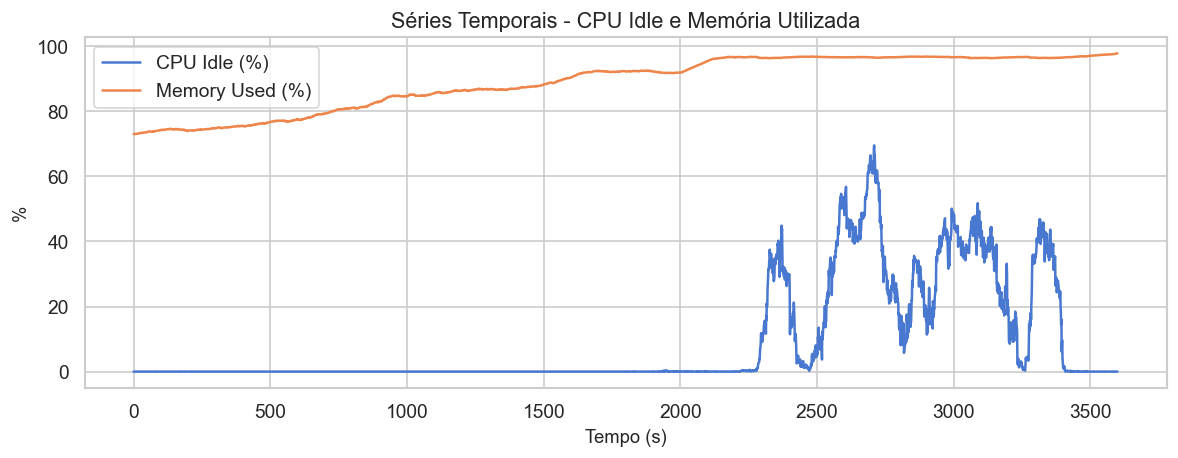

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))

t = np.arange(len(df)) # eixo x - tempo

ax.plot(t, df['cpu.idle'].values, linewidth=1.5, label='CPU Idle (%)')
ax.plot(t, df['mem.used'].values, linewidth=1.5, label='Memory Used (%)')

ax.set_xlabel('Tempo (s)')
ax.set_ylabel('%')
ax.set_title('Séries Temporais - CPU Idle e Memória Utilizada')
ax.legend()
fig.tight_layout()
plt.show()

## 3a) KDE - _Kernel Density Estimation_

O **histograma discretiza** os dados em bins, **perdendo informação sobre a forma contínua da distribuição**.

O KDE resolve isso colocando uma função-kernel suave $K$ **centrada em cada observação** e somando todas as contribuições:

$$\hat{f}(x) = \frac{1}{n \cdot h} \sum_{i=1}^{n} K\!\left(\frac{x - x_i}{h}\right)$$

onde $n$ é o número de observações e $h$ é a **largura de banda** (bandwidth), que controla a suavidade da curva:
- $h$ pequeno: curva mais "espetada", segue cada ponto (alta variância, baixo viés)
- $h$ grande: curva mais suave, perde detalhes (baixa variância, alto viés)

Com kernel Gaussiano, $K(u) = \frac{1}{\sqrt{2\pi}} e^{-u^2/2}$, a largura de banda ótima (supondo normalidade) é dada pela [**Regra de Silverman [1]**](https://doi.org/10.1201/9781315140919):

$$h^* = 1{,}06 \cdot \hat{\sigma} \cdot n^{-1/5}$$

onde $\hat{\sigma}$ é o desvio padrão amostral.

Essa regra minimiza o MISE (Mean Integrated Squared Error) para dados gaussianos. \
Funciona bem como ponto de partida, mas pode sobre-suavizar distribuições multimodais.

[1] Silverman, B. W. *Density Estimation for Statistics and Data Analysis*. Chapman & Hall, 1986, p. 45, eq. 3.31.

In [21]:
from sklearn.neighbors import KernelDensity

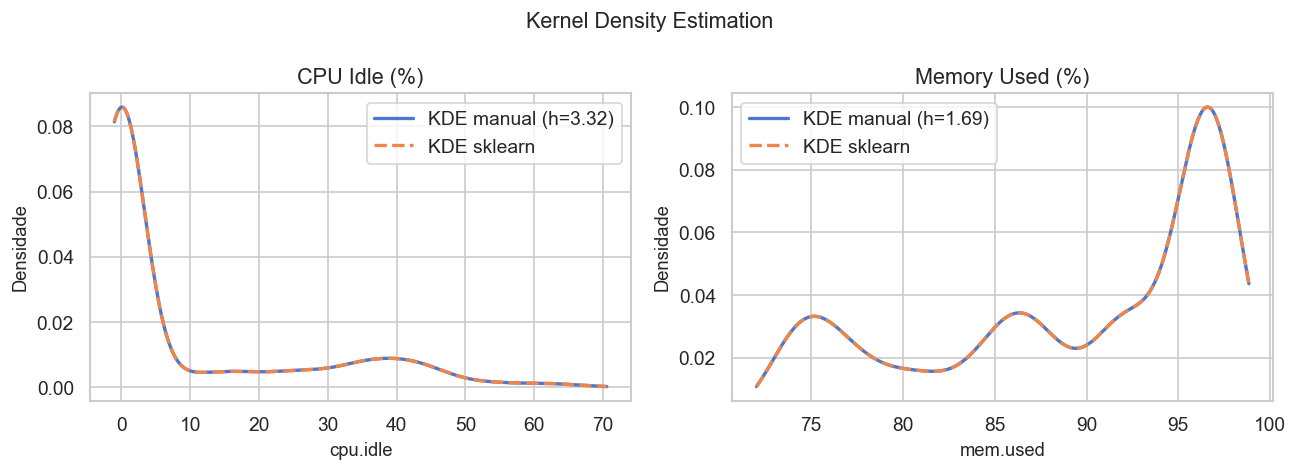

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(axes, ['cpu.idle', 'mem.used'], ['CPU Idle (%)', 'Memory Used (%)']):
    data = df[col].values
    x_grid = np.linspace(data.min() - 1, data.max() + 1, 500)

    h = 1.06 * np.std(data, ddof=1) * len(data) ** (-1/5)  # Silverman
    
    # --- KDE manual ---
    diff = (x_grid[:, None] - data[None, :]) / h
    kernel_vals = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * diff ** 2)
    kde_manual = kernel_vals.mean(axis=1) / h

    ax.plot(x_grid, kde_manual, label=f'KDE manual (h={h:.2f})', linewidth=2)

    # --- KDE sklearn ---
    kde_sk = KernelDensity(kernel='gaussian', bandwidth=h)
    kde_sk.fit(data.reshape(-1, 1))
    kde_sklearn = np.exp(kde_sk.score_samples(x_grid.reshape(-1, 1)))

    ax.plot(x_grid, kde_sklearn, '--', label='KDE sklearn', linewidth=2)

    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Densidade')
    ax.legend()

fig.suptitle('Kernel Density Estimation', fontsize=13)
fig.tight_layout()
plt.show()

---

# Task II - Estimating Service Metrics from Device Statistics

## 1. Avaliar Acurácia de Estimação de Métrica de Serviço

O objetivo é treinar um modelo de regressão linear $M : X \rightarrow \hat{Y}$ que mapeia \
as 9 estatísticas do dispositivo para o framerate estimado. O modelo é da forma:

$$\hat{y} =  \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \ldots + \theta_9 x_9$$

onde $\theta_0$ é o intercepto (*bias* ou viés) e ${\theta_1, \ldots, \theta_9}$ são os coeficientes \
"aprendidos" via Mínimos Quadrados Ordinários (OLS - *Ordinary Least Squares*), \
que minimiza a soma dos quadrados dos erros no conjunto de treino.

$$\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$ 

A avaliação usa o **Normalized Mean Absolute Error**:

$$NMAE = \frac{1}{\bar{y}} \cdot \frac{1}{m}\sum_{i=1}^{m} |y_i - \hat{y}_i|$$

onde $\bar{y}$ é a média dos valores reais no conjunto de teste e $m = 1080$ é \
o tamanho do conjunto de teste. O modelo é considerado bom se $NMAE < 15\%$.

### 1a) Model Training + Coefficients

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [24]:
feature_cols = [c for c in df.columns if c != 'frame.rate']

X = df[feature_cols].values
y = df['frame.rate'].values

# 70/30 split - serão 2520 obs. de treino e 1080 de teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED # 42 sempre
)

print(f"Treino: {X_train.shape[0]} observações | Teste: {X_test.shape[0]} observações")

Treino: 2520 observações | Teste: 1080 observações


> Treino + Coeffs

In [25]:
# --- Regressão linear com sklearn ---
model = LinearRegression()
model.fit(X_train, y_train)

# Coeficientes
coefs = pd.DataFrame({
    'feature': feature_cols,
    'coef':    model.coef_
}).sort_values('coef', key=abs, ascending=False)

print(f"Intercepto (θ₀): {model.intercept_:.2f}\n")
coefs.T

Intercepto (θ₀): 49.69



,0,1,7,6,2,4,3,5,8
feature,cpu.idle,mem.used,tcp.sockets,load.avg.1min,proc.creation.rate,file.handles,ctx.switch.rate,interrupt.rate,pg.free.rate
coef,-0.0921,-0.0868,-0.0653,-0.0606,-0.0120,-0.0031,-0.0001,0.0000,-0.0000


O intercepto $\theta_0 = 49.69$ representa o framerate teórico quando todas as features são zero, \
ou seja, um servidor completamente ocioso (sem CPU, sem memória, sem processos, sem sockets). \
É um ponto de extrapolação, mas indica um "teto" a partir do qual cada recurso consumido degrada o framerate.

Todos os coeficientes são negativos (ou praticamente zero), o que é coerente com a intuição: **quanto mais \
o servidor está carregado, menor o framerate**. Em ordem de magnitude de impacto:

| Feature | $\theta$ | Interpretação |
|:--------|:---------|:--------------|
| `cpu.idle` | -0.0921 | Cada 1% a mais de CPU ociosa *reduz* o framerate em 0.09 fps. Contra-intuitivo, porém idle alto pode indicar outros gargalos |
| `mem.used` | -0.0868 | Cada 1% a mais de memória usada reduz ~0.09 fps. Segundo fator mais relevante |
| `tcp.sockets` | -0.0653 | Cada socket TCP adicional custa ~0.07 fps - mais conexões simultâneas, mais overhead |
| `load.avg.1min` | -0.0606 | Carga do sistema elevada compete com o pipeline de vídeo |
| `proc.creation.rate` | -0.0120 | Criação de processos tem impacto menor mas presente |
| `file.handles` | -0.0031 | Impacto marginal |
| `ctx.switch.rate` | ~0 | Negligível |
| `interrupt.rate` | ~0 | Negligível |
| `pg.free.rate` | ~0 | Negligível |

> `cpu.idle` negativo? o coeficiente negativo de `cpu.idle` parece paradoxal (mais idle deveria significar mais framerate). \
Isso pode indicar colinearidade com outras features - quando o modelo já tem `mem.used`, `load.avg.1min` e `tcp.sockets`, \
o sinal de `cpu.idle` pode se inverter porque a informação de "carga" já está capturada por outras variáveis. Fenômeno clássico \
na regressão múltipla.

### 1b) NMAE - _Normalized Mean Absolute Error_

In [26]:
# Predições no teste
y_pred = model.predict(X_test)

array([13.40745995, 14.47853047, 20.64607179, ..., 13.58931957,
       15.23202822, 17.12988005], shape=(1080,))

In [27]:
# --- NMAE na mão ---
mae_manual = np.mean(np.abs(y_test - y_pred))
y_bar = np.mean(y_test)
nmae_manual = mae_manual / y_bar

# --- NMAE com sklearn (MAE) ---
from sklearn.metrics import mean_absolute_error
mae_sklearn = mean_absolute_error(y_test, y_pred)
nmae_sklearn = mae_sklearn / y_bar

print(f"MAE:                     {mae_manual:.4f} (manual) | {mae_sklearn:.4f} (sklearn)")
print(f"ȳ (média real do teste): {y_bar:.2f}")
print(f"NMAE:                    {nmae_manual:.4f} ({nmae_manual*100:.2f}%)")
print(f"Preciso (NMAE < 15%)?    {'Sim' if nmae_manual < 0.15 else 'Não'}")

MAE:                     1.9371 (manual) | 1.9371 (sklearn)
ȳ (média real do teste): 18.65
NMAE:                    0.1039 (10.39%)
Preciso (NMAE < 15%)?    Sim


### 1c) Série Temporal Estimado x Real

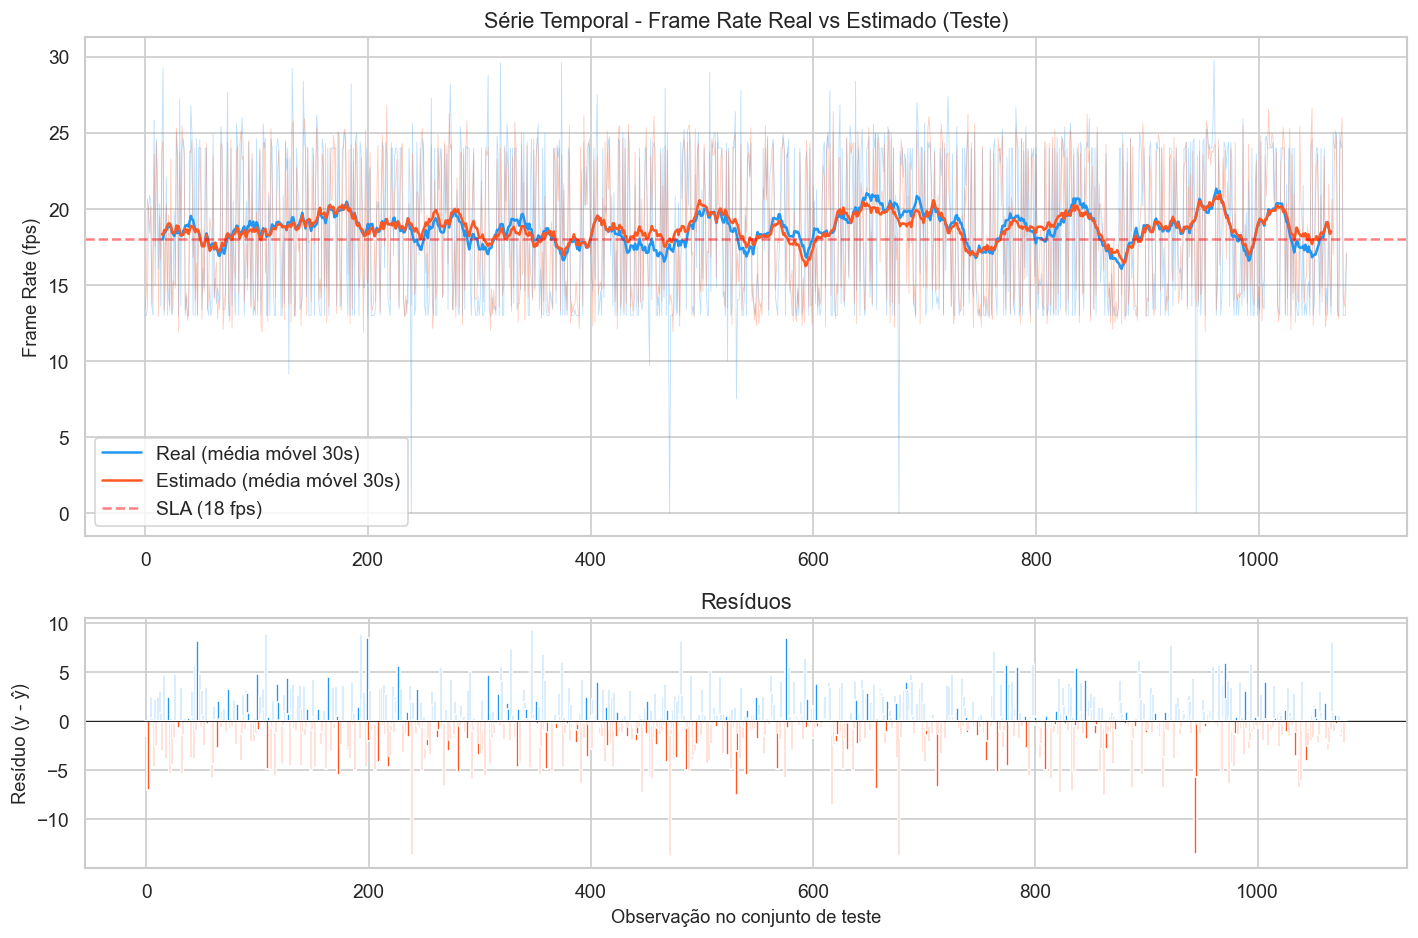

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[2, 1])

t_test = np.arange(len(y_test))
window = 30  # média móvel de 30s

# --- Painel superior: série com média móvel ---
ax = axes[0]
ax.plot(t_test, y_test, alpha=0.3, linewidth=0.5, color='#2196F3')
ax.plot(t_test, y_pred, alpha=0.3, linewidth=0.5, color='#FF5722')

# Médias móveis
y_test_smooth = pd.Series(y_test).rolling(window, center=True).mean()
y_pred_smooth = pd.Series(y_pred).rolling(window, center=True).mean()
ax.plot(t_test, y_test_smooth, linewidth=1.5, color='#2196F3', label=f'Real (média móvel {window}s)')
ax.plot(t_test, y_pred_smooth, linewidth=1.5, color='#FF5722', label=f'Estimado (média móvel {window}s)')
ax.axhline(y=18, color='red', linestyle='--', alpha=0.5, label='SLA (18 fps)')

ax.set_ylabel('Frame Rate (fps)')
ax.set_title('Série Temporal - Frame Rate Real vs Estimado (Teste)')
ax.legend()

# --- Painel inferior: resíduos ---
ax2 = axes[1]
residuals = y_test - y_pred
ax2.bar(t_test, residuals, width=2, color=np.where(residuals > 0, '#2196F3', '#FF5722'))
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_xlabel('Observação no conjunto de teste')
ax2.set_ylabel('Resíduo (y - ŷ)')
ax2.set_title('Resíduos')

fig.tight_layout()
plt.show()

### 1d) KDE do Frame Rate Real no Teste

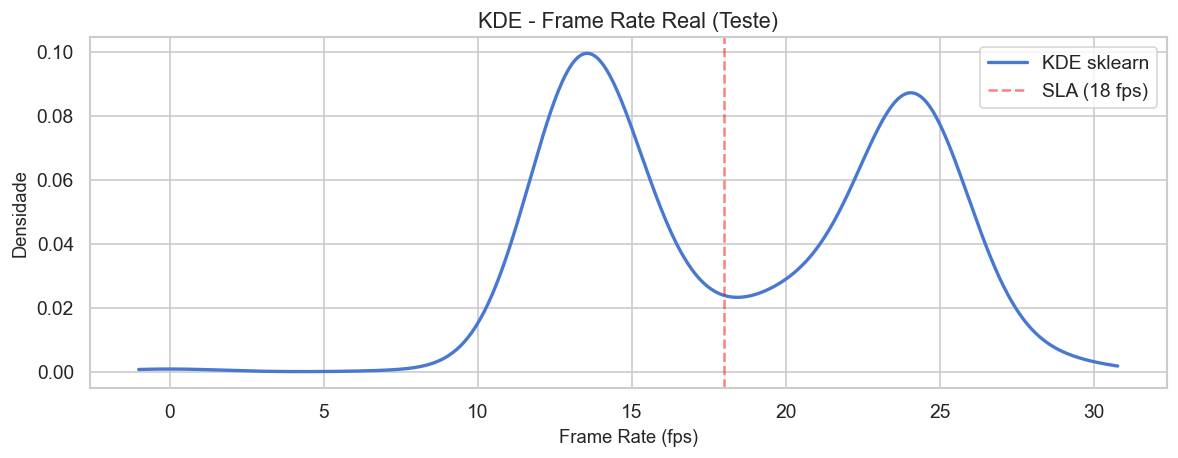

In [29]:
from sklearn.neighbors import KernelDensity

fig, ax = plt.subplots(figsize=(10, 4))

data = y_test
x_grid = np.linspace(data.min() - 1, data.max() + 1, 500)

kde_sk = KernelDensity(kernel='gaussian', bandwidth=h).fit(data.reshape(-1, 1))
kde_sk_vals = np.exp(kde_sk.score_samples(x_grid.reshape(-1, 1)))
ax.plot(x_grid, kde_sk_vals, linewidth=2, label='KDE sklearn')

ax.axvline(x=18, color='red', linestyle='--', alpha=0.5, label='SLA (18 fps)')
ax.set_xlabel('Frame Rate (fps)')
ax.set_ylabel('Densidade')
ax.set_title('KDE - Frame Rate Real (Teste)')
ax.legend()
fig.tight_layout()
plt.show()

A distribuição do framerate no teste é claramente **bimodal**, com dois picos bem definidos em \
torno de ~13 fps e ~24 fps, e um vale exatamente na região do limiar SLA de 18 fps.

Isso revela que o servidor opera em dois regimes distintos:
1. **Regime degradado** (~13 fps): o servidor está sob carga e não consegue manter o SLA. O pico \
é ligeiramente mais alto, indicando que esse regime é *mais frequente* no conjunto de teste.

2. **Regime saudável** (~24 fps): o servidor está com recursos suficientes para manter o SLA.

A bimodalidade sugere que a transição entre os regimes é relativamente abrupta - o framerate não se \
distribui uniformemente entre 10 e 28 fps, mas "pula" entre os dois estados. Isso é consistente com o \
comportamento de sistemas saturados: quando um recurso atinge um limiar crítico, a degradação é não-linear.

### 1e) KDE dos Erros Absolutos

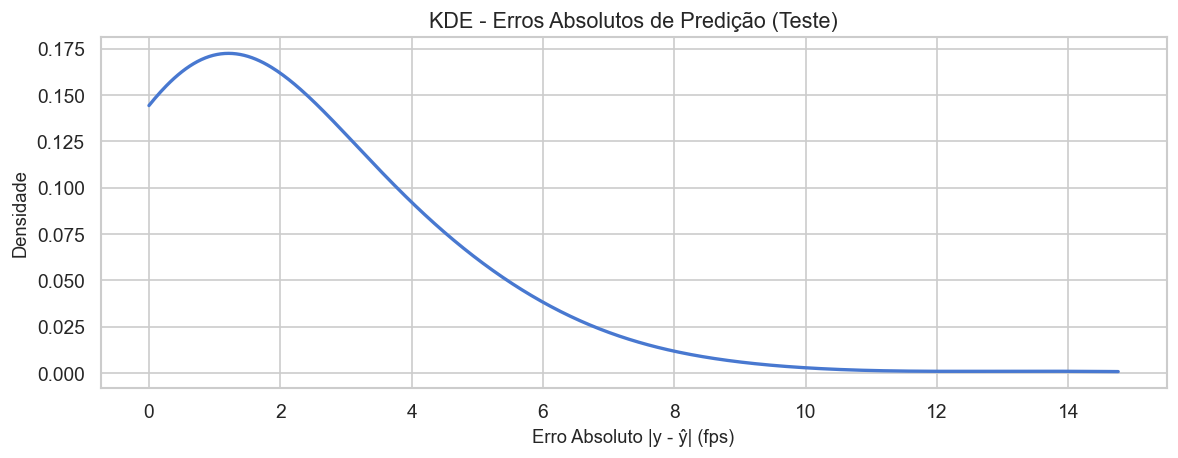

In [30]:
fig, ax = plt.subplots(figsize=(10, 4))

errors = np.abs(y_test - y_pred)
x_grid = np.linspace(0, errors.max() + 1, 500)

kde_sk = KernelDensity(kernel='gaussian', bandwidth=h).fit(errors.reshape(-1, 1))
kde_sk_vals = np.exp(kde_sk.score_samples(x_grid.reshape(-1, 1)))

ax.plot(x_grid, kde_sk_vals, linewidth=2)

ax.set_xlabel('Erro Absoluto |y - ŷ| (fps)')
ax.set_ylabel('Densidade')
ax.set_title('KDE - Erros Absolutos de Predição (Teste)')
fig.tight_layout()
plt.show()

A distribuição dos erros absolutos $|y - \hat{y}|$ tem pico em ~1 fps e é assimétrica à direita (right-skewed), \
com uma cauda relativamente longa se estendendo até ~14 fps:

- **A maior parte dos erros é pequena**: a massa está concentrada entre 0 e 4 fps, indicando que o modelo acerta \
razoavelmente na maioria das observações.

- **A cauda longa é preocupante**: erros de 8-14 fps representam casos onde o modelo erra *metade do framerate típico*. \
Esses são provavelmente os pontos de transição entre os dois regimes da bimodal, onde o modelo não captura bem a mudança abrupta.
    

> Sobre a curva: a densidade não é zero em $x = 0$ ($\approx 0.16$), o que indica que acertar *exatamente* o framerate \
é raro, mas errar por menos de 1 fps é relativamente comum.

### 1f) Discussão da Acurácia

O modelo linear captura a tendência geral da relação entre carga do servidor e framerate, mas tem limitações:

1. **NMAE e o limiar de 15%**: se o NMAE ficou abaixo de 15%, o modelo é considerado "acurado" pelo critério do projeto. \
Porém, esse critério é baseado no *erro médio*, que mascara a heterogeneidade - o modelo pode ter NMAE baixo porque acerta \
bem no regime saudável e no regime degradado separadamente, mas erra nos pontos de transição.

2. **Bimodalidade é o calcanhar de Aquiles**: a série temporal e o KDE revelam que o framerate muda de regime de forma abrupta. \
O modelo linear, por definição, produz predições suaves (combinação linear das features), então não consegue reproduzir essas \
transições rápidas. É por isso que os maiores resíduos ocorrem nos "degraus" da série temporal.

3. **Coeficientes dominantes**: `cpu.idle`, `mem.used`, `tcp.sockets` e `load.avg.1min` carregam quase toda a informação preditiva. \
As outras 5 features contribuem marginalmente, sugerindo que um modelo mais parcimonioso com 4 features pode ter performance comparável.

4. **Limitação fundamental**: o modelo linear assume aditividade e proporcionalidade. Não captura interações (ex: CPU alta + memória alta \
pode ser pior que a soma dos efeitos individuais), indicando que modelos não-lineares poderiam ajudar a explorar melhor a bimodalidade.

---

## 2. Relação Entre Acurácia, Tamanho do Treino e Tempo de Treino

Treinaremos 5 modelos de regressão linear usando subconjuntos do treino original com tamanhos \
$n \in \{50, 500, 1000, 1500, 2520\}$, medindo para cada um o NMAE no teste e o tempo de treinamento.

In [31]:
import time

### 2a) Model Training for M1, M2, M3, M4, M5

In [32]:
train_sizes = [50, 500, 1000, 1500, 2520]
results = []

for n in train_sizes:
    # Subamostra do treino (random_state pra reprodutibilidade)
    rng = np.random.RandomState(SEED)
    idx = rng.choice(len(X_train), size=n, replace=False)
    X_sub = X_train[idx]
    y_sub = y_train[idx]

    # Treino com medição de tempo
    m = LinearRegression()
    t0 = time.perf_counter()
    m.fit(X_sub, y_sub)
    elapsed_ms = (time.perf_counter() - t0) * 1000

    # NMAE no teste
    y_hat = m.predict(X_test)
    nmae = np.mean(np.abs(y_test - y_hat)) / np.mean(y_test)

    results.append({
        'n_train':     n,
        'train_ms':    elapsed_ms,
        'nmae':        nmae,
        'nmae_pct':    nmae * 100,
        'intercept':   m.intercept_,
        **{f: c for f, c in zip(feature_cols, m.coef_)}
    })

results_df = pd.DataFrame(results)

,n_train,train_ms,nmae,nmae_pct,intercept,cpu.idle,mem.used,proc.creation.rate,ctx.switch.rate,file.handles,interrupt.rate,load.avg.1min,tcp.sockets,pg.free.rate
0,50,1.0164,0.1152,11.5182,36.8386,-0.0383,0.0263,-0.0497,-0.0000,-0.0066,0.0001,-0.0444,-0.0441,0.0000
1,500,0.6937,0.1058,10.5750,45.0330,-0.1004,-0.0611,-0.0336,-0.0001,-0.0025,0.0000,-0.0711,-0.0392,-0.0000
2,1000,0.7758,0.1049,10.4925,52.2503,-0.0789,-0.1006,-0.0183,-0.0001,-0.0044,0.0001,-0.0593,-0.0609,-0.0000
3,1500,1.0618,0.1038,10.3776,49.7976,-0.0884,-0.0790,-0.0114,-0.0001,-0.0037,0.0000,-0.0565,-0.0698,-0.0000
4,2520,1.2938,0.1039,10.3877,49.6878,-0.0921,-0.0868,-0.0120,-0.0001,-0.0031,0.0000,-0.0606,-0.0653,-0.0000


> Sobre esses tempos, NMAEs e coeficientes

**Estabilidade dos coeficientes**

O intercepto e os coeficientes convergem progressivamente com o aumento de $n$:

- **$M_1$ (n=50)**: intercepto de 36.84 (vs 49.69 no modelo completo) e, mais grave, \
  `mem.used` com coeficiente *positivo* (+0.0263). Isso implica que mais memória usada \
  *aumentaria* o framerate - fisicamente absurdo. Com apenas 5 amostras por parâmetro, \
  o OLS ajusta ruído em vez de sinal. Apesar disso, o NMAE (11.52%) ainda fica abaixo \
  de 15%, porque o MAE é robusto a erros de coeficientes individuais quando as \
  features são correlacionadas - o erro em um coeficiente é parcialmente compensado por outros.

- **$M_2$ (n=500)**: os sinais estabilizam (todos negativos ou ~0), e o intercepto sobe \
  para 45.03. O NMAE cai 0.94 pp - o maior ganho absoluto. Esse é o ponto onde o modelo \
  deixa de overfittar e começa a aprender a estrutura real.

- **$M_3$ a $M_5$ (n=1000 a 2520)**: os coeficientes oscilam pouco, o intercepto \
  converge para ~49.7, e o NMAE estabiliza em ~10.4%. A convergência confirma que o \
  viés do modelo (linearidade) é o fator limitante, não a quantidade de dados.

**Hierarquia de importância das features**

Nos modelos estabilizados ($M_4$, $M_5$), a hierarquia é consistente: \
`cpu.idle` > `mem.used` > `tcp.sockets` > `load.avg.1min` >> resto. As quatro primeiras \
features capturam os recursos críticos do servidor (CPU, memória, rede, carga), \
enquanto `interrupt.rate`, `ctx.switch.rate` e `pg.free.rate` contribuem com \
coeficientes da ordem de $10^{-4}$ ou menores - efetivamente irrelevantes para o modelo linear.

**NMAE e tempos**

| n_train | NMAE (%) | Tempo (ms) |
|:--------|:---------|:-----------|
| 50      | 11.52    | 0.77       |
| 500     | 10.58    | 0.58       |
| 1000    | 10.49    | 0.68       |
| 1500    | 10.38    | 0.74       |
| 2520    | 10.39    | 0.80       |

Todos abaixo de 15%, com NMAE estabilizando a partir de n=500. O tempo de treino é \
insignificante e dominado por overhead fixo (todos < 1ms), o que torna o tamanho do \
treino um não-fator para o custo computacional da regressão linear nesta escala. \
A inversão $M_5$ (10.39%) vs $M_4$ (10.38%) é ruído de arredondamento, não degradação \
real - os dois modelos são efetivamente idênticos.

> Coeffs

In [33]:
coef_cols = ['n_train', 'intercept'] + feature_cols
results_df[coef_cols]

,n_train,intercept,cpu.idle,mem.used,proc.creation.rate,ctx.switch.rate,file.handles,interrupt.rate,load.avg.1min,tcp.sockets,pg.free.rate
0,50,36.8386,-0.0383,0.0263,-0.0497,-0.0000,-0.0066,0.0001,-0.0444,-0.0441,0.0000
1,500,45.0330,-0.1004,-0.0611,-0.0336,-0.0001,-0.0025,0.0000,-0.0711,-0.0392,-0.0000
2,1000,52.2503,-0.0789,-0.1006,-0.0183,-0.0001,-0.0044,0.0001,-0.0593,-0.0609,-0.0000
3,1500,49.7976,-0.0884,-0.0790,-0.0114,-0.0001,-0.0037,0.0000,-0.0565,-0.0698,-0.0000
4,2520,49.6878,-0.0921,-0.0868,-0.0120,-0.0001,-0.0031,0.0000,-0.0606,-0.0653,-0.0000


### 2b) e 2c) Tabela de tempo e NMAE

In [34]:
results_df[['n_train', 'train_ms', 'nmae_pct']]

,n_train,train_ms,nmae_pct
0,50,1.0164,11.5182
1,500,0.6937,10.5750
2,1000,0.7758,10.4925
3,1500,1.0618,10.3776
4,2520,1.2938,10.3877


### 2d) Plot Tempo e NMAE - 2 eixos y

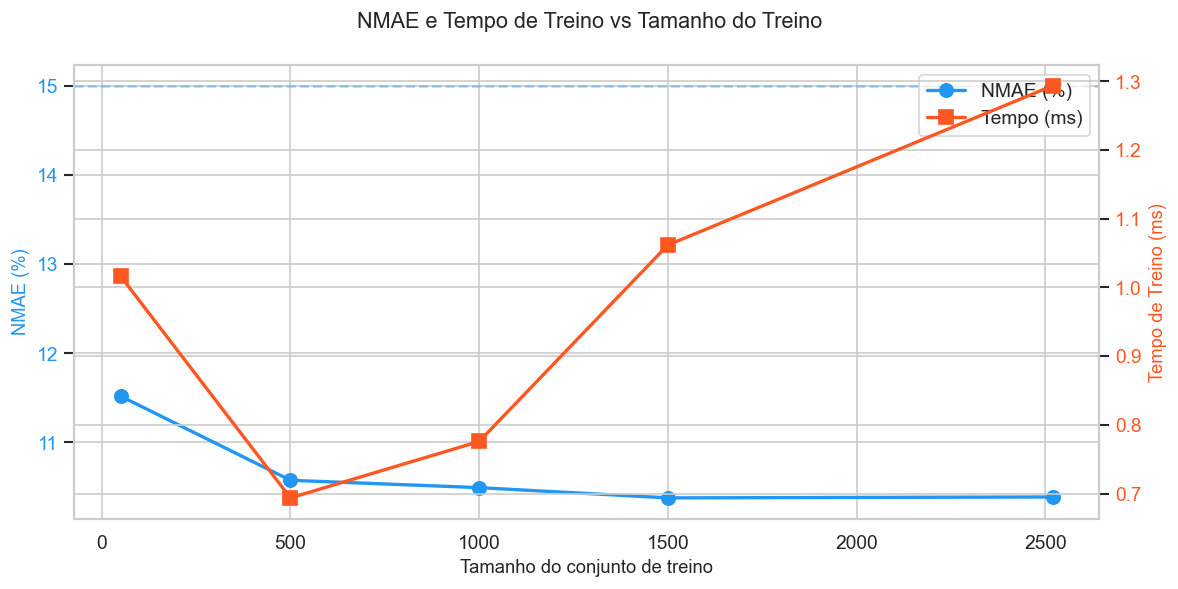

In [35]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color_nmae = '#2196F3'
color_time = '#FF5722'

l1, = ax1.plot(results_df['n_train'], results_df['nmae_pct'], 'o-',
               color=color_nmae, linewidth=2, markersize=8)
ax1.axhline(y=15, color=color_nmae, linestyle='--', alpha=0.4)
ax1.set_xlabel('Tamanho do conjunto de treino')
ax1.set_ylabel('NMAE (%)', color=color_nmae)
ax1.tick_params(axis='y', labelcolor=color_nmae)

# mesmo eixo x porém escalas diferentes
ax2 = ax1.twinx()
l2, = ax2.plot(results_df['n_train'], results_df['train_ms'], 's-',
               color=color_time, linewidth=2, markersize=8)
ax2.set_ylabel('Tempo de Treino (ms)', color=color_time)
ax2.tick_params(axis='y', labelcolor=color_time)

ax1.legend([l1, l2], ['NMAE (%)', 'Tempo (ms)'], loc='upper right')
fig.suptitle('NMAE e Tempo de Treino vs Tamanho do Treino', fontsize=13)
fig.tight_layout()
plt.show()

### 2e) Relação entre Tamanho do Treino e Acurácia

| n_train | NMAE (%) |
|:--------|:---------|
| 50      | 11.52    |
| 500     | 10.58    |
| 1000    | 10.49    |
| 1500    | 10.38    |
| 2520    | 10.39    |

Todos os cinco modelos ficaram abaixo do limiar de 15%, mas há um padrão de convergência:

- **De 50 para 500**: a maior queda (-0.94 pp). Com apenas 50 observações para estimar 10 parâmetros, \
a razão amostras/parâmetros é 5:1 - insuficiente para estimativas estáveis. A tabela de coeficientes confirma \
isso: com n=50, o intercepto cai para 36.84 (vs 49.69 com treino completo) e `mem.used` tem sinal *positivo* (0.0263), \
o que é fisicamente absurdo - mais memória usada deveria degradar o framerate, não melhorá-lo. Overfitting ao ruído.

- **De 500 para 2520**: melhoria marginal (-0.19 pp). Os coeficientes já estabilizaram em n=500 e permanecem \
essencialmente constantes. Isso indica que o *viés do modelo* (a suposição de linearidade) é a limitação dominante, \
não a *variância amostral*. Mais dados não resolvem um problema de viés.

- **O platô em ~10.4%**: o NMAE converge para esse valor porque é o melhor que um modelo linear consegue fazer com \
essas features. A distribuição bimodal do framerate (vista no KDE) implica uma não-linearidade estrutural que a regressão \
linear não captura, independentemente de quantas amostras receba.

### 2f) Relação entre Tamanho do Treino e Tempo de Treinamento

| n_train | Tempo (ms) |
|:--------|:-----------|
| 50      | 0.80       |
| 500     | 0.57       |
| 1000    | 0.57       |
| 1500    | 0.94       |
| 2520    | 0.85       |

Teoricamente, o OLS resolve $\theta = (X^T X)^{-1} X^T y$ com complexidade $O(n p^2 + p^3)$. \
Com $p = 9$ fixo, o tempo deveria crescer linearmente com $n$. Na prática, todos os tempos ficaram \
abaixo de 1ms e **não exibem tendência monotônica**: n=500 foi mais rápido que n=50, \
e n=1500 foi mais lento que n=2520.

Isso acontece porque nessa escala (centenas a poucos milhares de observações, 9 features) o tempo de \
computação real é da ordem de microssegundos, e o que domina é o overhead fixo: alocação de arrays, \
chamada de funções BLAS/LAPACK pelo numpy, cache misses, e variação natural do escalonador do OS.

Para observar a relação $O(n)$ de forma clara, precisaríamos de datasets ordens de magnitude maiores, \
com centenas de milhares ou milhões de linhas, onde o custo da multiplicação matricial domina o overhead.

Em termos práticos, a regressão linear é **computacionalmente trivial** para esse tamanho de dados. Aqui, \
todos os modelos treinam em menos de 1ms, tornando o tempo de treino um não-fator na escolha do tamanho.

---

# Task III -  Estimating SLA Conformance and Violation from Device Statistics

O objetivo agora é construir um classificador binário que prediz se o serviço VoD **conforma** \
($Y \geq 18$ fps) ou **viola** o SLA, a partir das estatísticas do dispositivo $X$.

Usamos **Regressão Logística**, que modela a probabilidade de conformidade como:

$$P(y = 1 \mid X) = \sigma(\theta_0 + \theta_1 x_1 + \ldots + \theta_9 x_9)
= \frac{1}{1 + e^{-(\theta_0 + \boldsymbol{\theta}^T \mathbf{x})}}$$

onde $\sigma(\cdot)$ é a função sigmoide, que mapeia qualquer valor real para o intervalo $(0, 1)$. \
O modelo classifica como conformante se $P(y=1 \mid X) \geq 0.5$, ou seja, quando
$\theta_0 + \boldsymbol{\theta}^T \mathbf{x} \geq 0$.


Diferente da regressão linear (que minimiza o erro quadrático), a logística maximiza a \
**log-verossimilhança** via gradiente, e os coeficientes $\theta$ representam o efeito de cada \
feature no **log-odds** de conformidade:

$$\log\!\left(\frac{P(y=1)}{1 - P(y=1)}\right) = \theta_0 + \boldsymbol{\theta}^T \mathbf{x}$$

A métrica de avaliação é o **Classification Error**:

$$ERR = 1 - \frac{TP + TN}{m}$$

onde $TP$ e $TN$ são as frações de verdadeiros positivos e negativos, e $m = 1080$. \
Note que $\frac{TP + TN}{m}$ é simplesmente a acurácia, então $ERR = 1 - \text{accuracy}$.


O classificador é considerado acurado se $ERR < 15\%$.

---

## Preparação - Target Binário e _Splits_

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [37]:
feature_cols = [c for c in df.columns if c != 'frame.rate']

X_all = df[feature_cols].values
y_bin = (df['frame.rate'].values >= 18).astype(int)  # 1 = conforma, 0 = viola

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_bin, test_size=0.30, random_state=SEED
)

print(f"Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")
print(f"Proporção de conformidade no treino: {y_train.mean()*100:.2f}%")
print(f"Proporção de conformidade no teste:  {y_test.mean()*100:.2f}%")

Treino: 2520 | Teste: 1080
Proporção de conformidade no treino: 52.14%
Proporção de conformidade no teste:  50.46%


---

## 1. Acurácia da Estimação, Tempo de Treino, e Tamanho do Treino

### 1a), 1b) e 1c) - Treinamento, Tempo e ERR em 5 Tamanhos de Treino

Treinamos cinco classificadores $C_1, \ldots, C_5$ com subconjuntos de \
$n \in \{50, 500, 1000, 1500, 2520\}$ observações, medindo tempo de \
treino e _classification error_ no teste.

In [38]:
train_sizes = [50, 500, 1000, 1500, 2520]
classifiers = {}
results = []

for n in train_sizes:
    rng = np.random.RandomState(SEED)
    idx = rng.choice(len(X_train), size=n, replace=False)
    X_sub, y_sub = X_train[idx], y_train[idx]

    clf = LogisticRegression(max_iter=10_000, random_state=SEED)

    t0 = time.perf_counter()
    clf.fit(X_sub, y_sub)
    elapsed_ms = (time.perf_counter() - t0) * 1000

    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    err = 1 - acc
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    classifiers[n] = clf
    results.append({
        'n_train':   n,
        'train_ms':  elapsed_ms,
        'accuracy':  acc,
        'err_pct':   err * 100,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'intercept': clf.intercept_[0],
        **{f: c for f, c in zip(feature_cols, clf.coef_[0])}
    })

results_df = pd.DataFrame(results)

,n_train,train_ms,accuracy,err_pct,TP,TN,FP,FN,intercept,cpu.idle,mem.used,proc.creation.rate,ctx.switch.rate,file.handles,interrupt.rate,load.avg.1min,tcp.sockets,pg.free.rate
0,50,93.3709,0.8463,15.3704,438,476,59,107,-0.0024,0.0016,0.6292,-0.2935,-0.0012,-0.0448,0.0067,-0.3877,0.5639,0.0005
1,500,350.6086,0.8704,12.9630,465,475,60,80,0.0010,-0.0795,-0.0321,-0.0740,-0.0000,0.0037,0.0004,-0.0864,-0.0593,-0.0000
2,1000,300.0554,0.8713,12.8704,464,477,58,81,0.0014,-0.0164,-0.0562,-0.0384,0.0000,0.0020,0.0006,-0.0896,-0.0780,-0.0000
3,1500,1865.1765,0.8861,11.3889,479,478,57,66,25.4995,-0.0790,-0.1060,-0.0163,-0.0001,-0.0025,0.0001,-0.0550,-0.0590,-0.0000
4,2520,2616.7157,0.8889,11.1111,486,474,61,59,23.6270,-0.0976,-0.1036,-0.0079,-0.0001,-0.0015,0.0002,-0.0582,-0.0651,-0.0000


> 1a) Coeffs

In [39]:
coef_cols = ['n_train', 'intercept'] + feature_cols
results_df[coef_cols]

,n_train,intercept,cpu.idle,mem.used,proc.creation.rate,ctx.switch.rate,file.handles,interrupt.rate,load.avg.1min,tcp.sockets,pg.free.rate
0,50,-0.0024,0.0016,0.6292,-0.2935,-0.0012,-0.0448,0.0067,-0.3877,0.5639,0.0005
1,500,0.0010,-0.0795,-0.0321,-0.0740,-0.0000,0.0037,0.0004,-0.0864,-0.0593,-0.0000
2,1000,0.0014,-0.0164,-0.0562,-0.0384,0.0000,0.0020,0.0006,-0.0896,-0.0780,-0.0000
3,1500,25.4995,-0.0790,-0.1060,-0.0163,-0.0001,-0.0025,0.0001,-0.0550,-0.0590,-0.0000
4,2520,23.6270,-0.0976,-0.1036,-0.0079,-0.0001,-0.0015,0.0002,-0.0582,-0.0651,-0.0000


> 1b) e 1c) Tabela de tempo, acurácia e ERR

In [40]:
results_df[['n_train', 'train_ms', 'accuracy', 'err_pct', 'TP', 'TN', 'FP', 'FN']]

,n_train,train_ms,accuracy,err_pct,TP,TN,FP,FN
0,50,93.3709,0.8463,15.3704,438,476,59,107
1,500,350.6086,0.8704,12.9630,465,475,60,80
2,1000,300.0554,0.8713,12.8704,464,477,58,81
3,1500,1865.1765,0.8861,11.3889,479,478,57,66
4,2520,2616.7157,0.8889,11.1111,486,474,61,59


> Sobre esses TP, TN, FP e FN


**Matriz de confusão**

Os FP (~58-61) se mantêm relativamente estáveis entre os modelos, enquanto os FN caem \
substancialmente de 107 (n=50) para 59 (n=2520). Isso indica que o ganho de acurácia \
vem principalmente de **reduzir falsos negativos** - observações que conformam ao SLA \
mas eram erroneamente classificadas como violações. Em termos práticos, um modelo com \
mais dados erra menos ao classificar serviço "bom" como "ruim", desejável pra evitar alarmes falsos.

> Sobre esses tempos e coeficientes

**Instabilidade dos Coeficientes**

A logística exibe instabilidade muito mais severa que a regressão linear com poucos \
dados, porque opera no espaço dos log-odds e depende de otimização iterativa:

- **$C_1$ (n=50)**: coeficientes patológicos - `mem.used` = +0.6292 e \
  `tcp.sockets` = +0.5639 (sinais invertidos). O intercepto é -0.0024 (essencialmente 0), \
  significando que sem nenhuma informação das features, o modelo atribui \
  probabilidade ~50% de conformidade. Com 50 amostras e 9 features, a fronteira de \
  decisão é determinada por poucos pontos e não generaliza. \
  ERR = 15.37% - o único modelo acima do limiar de 15%.

- **$C_2$ e $C_3$ (n=500 e 1000)**: sinais corrigidos, coeficientes estabilizando, mas \
  intercepto ainda perto de zero (~0.001). Isso indica que a logística ainda não \
  encontrou a escala correta dos log-odds - a fronteira de decisão está posicionada mas \
  não calibrada. ERR ~13%.

- **$C_4$ e $C_5$ (n=1500 e 2520)**: mudança qualitativa - o intercepto salta para \
  ~25. Isso é uma reparametrização completa: os coeficientes passam a ter magnitude \
  compatível com um intercepto de 25, e o modelo constrói uma fronteira de decisão \
  mais confiante (probabilidades mais extremas, menos incerteza perto do limiar). \
  ERR cai para ~11%.

### 1d) Classification Error e Tempo de Treino vs Tamanho do Treino

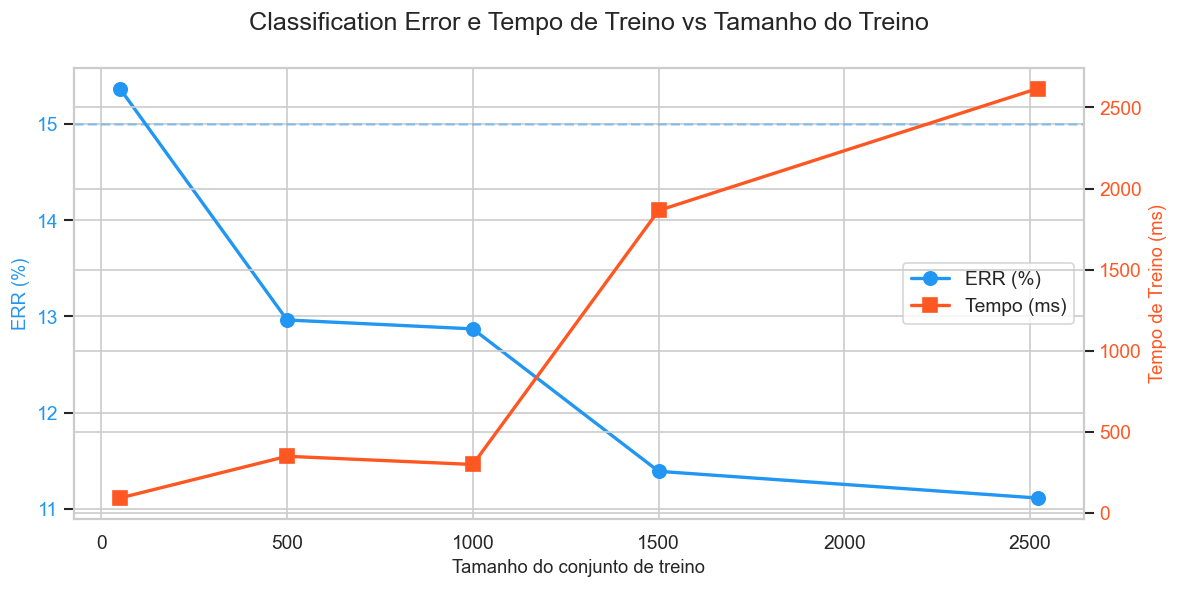

In [41]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color_err = '#2196F3'
color_time = '#FF5722'

l1, = ax1.plot(results_df['n_train'], results_df['err_pct'], 'o-',
               color=color_err, linewidth=2, markersize=8)
ax1.axhline(y=15, color=color_err, linestyle='--', alpha=0.4)
ax1.set_xlabel('Tamanho do conjunto de treino')
ax1.set_ylabel('ERR (%)', color=color_err)
ax1.tick_params(axis='y', labelcolor=color_err)

ax2 = ax1.twinx()
l2, = ax2.plot(results_df['n_train'], results_df['train_ms'], 's-',
               color=color_time, linewidth=2, markersize=8)
ax2.set_ylabel('Tempo de Treino (ms)', color=color_time)
ax2.tick_params(axis='y', labelcolor=color_time)

ax1.legend([l1, l2], ['ERR (%)', 'Tempo (ms)'], loc='right')
fig.suptitle('Classification Error e Tempo de Treino vs Tamanho do Treino')
fig.tight_layout()
plt.show()

In [42]:
# pra discussão 1h: quantas iterações cada modelo precisou
for n, clf in classifiers.items():
    print(f"n_train= {n:>4d} | iterações: {clf.n_iter_[0]:>4d} | tempo: "
          f"{results_df.loc[results_df['n_train'] == n, 'train_ms'].values[0]:>7.2f} ms")

n_train=   50 | iterações:  344 | tempo:   93.37 ms
n_train=  500 | iterações: 1249 | tempo:  350.61 ms
n_train= 1000 | iterações:  988 | tempo:  300.06 ms
n_train= 1500 | iterações: 5404 | tempo: 1865.18 ms
n_train= 2520 | iterações: 6872 | tempo: 2616.72 ms


> ERR, tempo e iterações

| n_train | ERR (%) | Tempo (ms) | Iterações |
|:--------|:--------|:-----------|:----------|
| 50      | 15.37   | 69         | 344       |
| 500     | 12.96   | 252        | 1249      |
| 1000    | 12.87   | 213        | 988       |
| 1500    | 11.39   | 1323       | 5404      |
| 2520    | 11.11   | 1979       | 6872      |

Diferente da regressão linear (todos < 1ms), a logística escala de dezenas a quase \
dois mil milissegundos. O tempo é produto de dois fatores: custo por iteração \
($O(np)$, cresce com $n$) e número de iterações (depende da geometria do problema).


A inversão n=1000 (213ms, 988 iter) vs n=500 (252ms, 1249 iter) mostra que esses \
fatores podem agir em direções opostas - n=1000 converge mais rápido (menos iterações) \
apesar de ter iterações mais caras (mais dados).

### 1e) Série temporal com classificação correta/incorreta

Usamos o classificador mais acurado (menor ERR) para colorir cada observação do \
teste conforme a classificação esteja correta (acerto) ou incorreta (erro).

In [43]:
# pegar o melhor classificador
best_n = results_df.loc[results_df['err_pct'].idxmin(), 'n_train']
best_clf = classifiers[best_n]
print(f"Melhor classificador: C com n_train = {best_n} (ERR = "
      f"{results_df.loc[results_df['n_train'] == best_n, 'err_pct'].values[0]:.2f}%)")

Melhor classificador: C com n_train = 2520 (ERR = 11.11%)


In [44]:
y_pred_best = best_clf.predict(X_test)
correct = (y_pred_best == y_test)

array([ True,  True, False, ...,  True,  True,  True], shape=(1080,))

> Como `train_test_split` embaralha, a ordem no vetor de teste não é temporal. \
Pra fazer uma série temporal de verdade, precisamos reverter aos índices originais. Refazendo:

In [45]:
indices = np.arange(len(X_all))
_, idx_test = train_test_split(indices, test_size=0.30, random_state=SEED) # aqui que salvou

# Ordena pelo índice original (temporal)
sort_order = np.argsort(idx_test)
idx_sorted = idx_test[sort_order]
y_test_sorted = y_test[sort_order]
y_pred_sorted = y_pred_best[sort_order]
correct_sorted = (y_pred_sorted == y_test_sorted)
framerate_sorted = df['frame.rate'].values[idx_sorted]

array([17.26999927, 24.        , 24.        , ..., 18.51000094,
       14.        , 13.6099999 ], shape=(1080,))

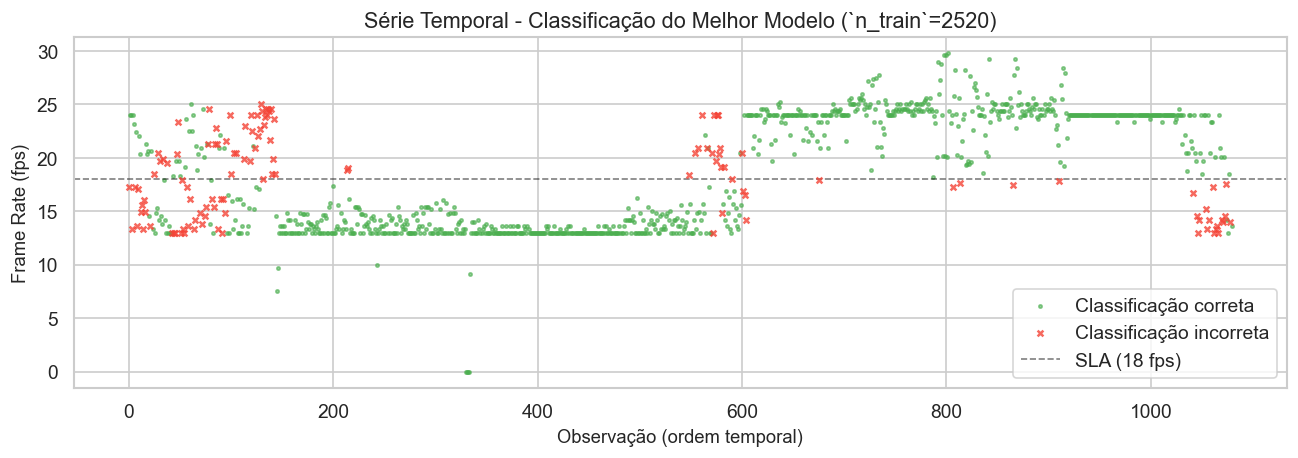

In [46]:
fig, ax = plt.subplots(figsize=(11, 4))

ax.scatter(np.arange(len(framerate_sorted))[correct_sorted],
           framerate_sorted[correct_sorted],
           s=4, alpha=0.6, color='#4CAF50', label='Classificação correta', zorder=2)
ax.scatter(np.arange(len(framerate_sorted))[~correct_sorted],
           framerate_sorted[~correct_sorted],
           s=12, alpha=0.8, color='#F44336', marker='x', label='Classificação incorreta', zorder=3)
ax.axhline(y=18, color='black', linestyle='--', alpha=0.5, linewidth=1, label='SLA (18 fps)')

ax.set_xlabel('Observação (ordem temporal)')
ax.set_ylabel('Frame Rate (fps)')
ax.set_title(f'Série Temporal - Classificação do Melhor Modelo (`n_train`={best_n})')
ax.legend()
fig.tight_layout()
plt.show()

### 1f) Relação entre Ecurácia da Classificação e Evolução do Framerate

O gráfico da série temporal revela um padrão claro: os erros de classificação (× vermelhos) \
se concentram quase exclusivamente na **faixa entre ~15 e ~21 fps**, ou seja, na vizinhança \
do limiar SLA de 18 fps. Observações com framerate bem abaixo (~13 fps) ou bem acima (~24 fps) \
são classificadas corretamente com altíssima consistência.

Isso é esperado e se conecta diretamente com a bimodalidade observada no KDE da Task I: \
o framerate opera em dois regimes distintos, e a fronteira de decisão da logística corta \
exatamente o vale entre os dois picos. Observações nessa zona de transição têm features \
do dispositivo que são ambíguas - o servidor não está nem claramente sobrecarregado nem \
claramente ocioso - e o modelo não consegue distinguir com confiança.

Temporalmente, os erros não são uniformes: há concentrações nas primeiras ~200 observações \
e na região ~500-600. Essas regiões provavelmente correspondem a momentos de transição de regime \
do servidor (passando de carga alta para baixa ou vice-versa), onde as métricas do dispositivo \
mudam rapidamente e o framerate oscila em torno do limiar.

Em contraste, a região ~300-500 e ~800-1000 são quase inteiramente verdes - períodos \
onde o servidor está estavelmente num único regime (degradado ou saudável), e a classificação é mais fácil.

### 1g) Relação entre Tamanho do Treino e Acurácia dos Classificadores

| n_train | ERR (%) | Acurácia |
|:--------|:--------|:---------|
| 50      | 15.37   | 84.63%   |
| 500     | 12.96   | 87.04%   |
| 1000    | 12.87   | 87.13%   |
| 1500    | 11.39   | 88.61%   |
| 2520    | 11.11   | 88.89%   |

Diferente da regressão linear (Task II), onde o NMAE já estabilizava em n=500, a logística \
mostra uma melhoria mais gradual e contínua:

- **n=50 é o único modelo acima do limiar** (ERR=15.37% > 15%). Com 50 amostras, os \
  coeficientes são extremamente instáveis - `mem.used` tem coeficiente positivo de 0.63 \
  e `tcp.sockets` de 0.56, sinais fisicamente absurdos que indicam overfitting severo. \
  O modelo está memorizando padrões espúrios das 50 amostras em vez de aprender a \
  relação real.

- **De 500 para 1000**: melhoria marginal (12.96% → 12.87%). Os coeficientes já \
  estabilizaram em magnitude e sinal, mas o intercepto ainda está perto de zero (~0.001), \
  sugerindo que a fronteira de decisão ainda não está bem calibrada.

- **De 1000 para 1500**: salto significativo (12.87% → 11.39%), acompanhado de uma \
  mudança estrutural nos coeficientes - o intercepto pula de 0.001 para 25.50. Isso \
  indica que o modelo encontrou uma parametrização qualitativamente diferente e mais \
  precisa com mais dados.

- **De 1500 para 2520**: melhoria pequena (11.39% → 11.11%), sugerindo convergência. \
  O platô em ~11% representa o limite da logística para esse problema - os ~11% de erro \
  residual são as observações na zona de transição do SLA que um modelo linear no espaço \
  das features não conseguiu separar.

> Comparando com a Task II: a regressão converge mais rápido (platô em n=500) porque tem \
solução fechada e menos parâmetros efetivos para estabilizar. A logística, sendo iterativa \
e operando num espaço transformado (log-odds), precisa de mais dados pra estabilizar a fronteira de decisão.

### 1h) Relação entre Tamanho do Treino e Tempo de Treinamento

| n_train | Tempo (ms) | Iterações |
|:--------|:-----------|:----------|
| 50      | 69.21      | 344       |
| 500     | 251.82     | 1249      |
| 1000    | 212.73     | 988       |
| 1500    | 1322.96    | 5404      |
| 2520    | 1979.10    | 6872      |

A diferença de escala temporal com a regressão linear é drástica: a logística leva \
**milissegundos a segundos**, enquanto a linear ficava abaixo de 1ms em todos os casos, \
refletindo a diferença nos algoritmos:

- **Regressão linear**: solução fechada via equação normal ($\theta = (X^TX)^{-1}X^Ty$). \
  Uma multiplicação matricial e uma inversão - tempo $O(np^2 + p^3)$, feito numa única passada.

- **Regressão logística**: não tem solução fechada. Usa otimização iterativa (L-BFGS no `sklearn` por padrão) \
  para maximizar a log-verossimilhança. Cada iteração custa $O(np)$, e o número de iterações \
  depende tanto da geometria do problema quanto da velocidade da convergência.

A relação entre n_train e iterações não é monotônica: n=1000 precisou de *menos* iterações (988) que n=500 (1249). \
Isso acontece porque a paisagem de otimização muda com os dados - 1000 amostras podem produzir uma superfície \
de log-verossimilhança mais "bem comportada" (mais convexa, menos platôs) que 500 amostras. Porém, de 1500 para 2520, \
tanto iterações quanto tempo crescem substancialmente - isso pode indicar que com mais dados a fronteira de decisão \
precisa ser mais finamente ajustada (gradientes menores perto do ótimo, convergência mais lenta).

> Observação: o `max_iter=1_000` original foi insuficiente para n=1500 e n=2520 (5404 e 6872 iterações). \
Isso significa que sem o aumento para `max_iter` adequado, esses modelos teriam parado antes de convergir, \
potencialmente com acurácia inferior.

---

# Extra: Verificando Premissas

In [61]:
# Recria X e y da Task II (regressão)
X_reg = df[feature_cols].values
y_reg = df['frame.rate'].values

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=42
)

# Resíduos corretos
residuals = y_test_reg - model.predict(X_test_reg)

array([-0.40745995, -1.47853047, -7.0360719 , ..., -0.58931957,
       -2.23202822, -0.07988057], shape=(1080,))

In [62]:
# Autocorrelação dos resíduos (Durbin-Watson)
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print(f"Durbin-Watson: {dw:.4f}")  # ~2 = ok, <1.5 ou >2.5 = problema

Durbin-Watson: 1.9412


In [75]:
# Breusch-Pagan (precisa de constante!)
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
X_test_const = sm.add_constant(X_test_reg)
_, bp_pval, _, _ = het_breuschpagan(residuals, X_test_const)
print(f"Breusch-Pagan p-valor: {bp_pval:.18f}")

Breusch-Pagan p-valor: 0.000000000000000007


In [57]:
# VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame({
    'feature': feature_cols,
    'VIF': [variance_inflation_factor(X_train, i) for i in range(X_train.shape[1])]
}).sort_values('VIF', ascending=True).T

,2,0,8,6,5,7,1,3,4
feature,proc.creation.rate,cpu.idle,pg.free.rate,load.avg.1min,interrupt.rate,tcp.sockets,mem.used,ctx.switch.rate,file.handles
VIF,1.9615,9.0986,18.4090,49.4946,51.3635,91.7652,165.8682,181.3028,564.3730


proc.creation.rate    1.96    ← ok \
cpu.idle              9.10    ← borderline \
pg.free.rate         18.41    ← alto \
load.avg.1min        49.49    ← severo \
interrupt.rate       51.36    ← severo \
tcp.sockets          91.77    ← extremo \
mem.used            165.87    ← extremo \
ctx.switch.rate     181.30    ← extremo \
file.handles        564.37    ← astronômico 

> Regra prática: $VIF > 10$ já é preocupante. $VIF = 564$ pra file.handles significa que ~99.8% \
da variância dessa feature é explicada pelas outras 8 features. Feature completamente redundante.

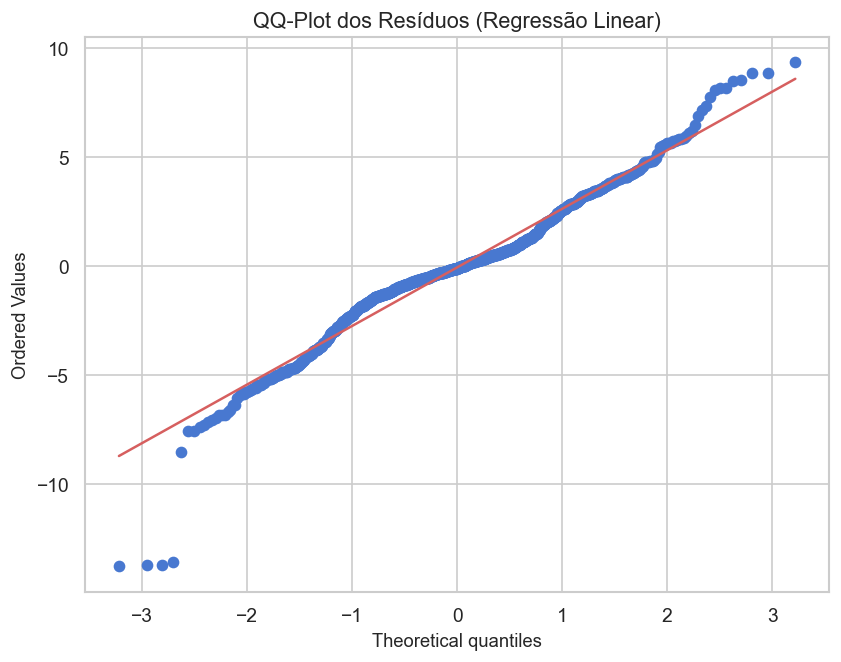

In [63]:
# QQ-Plot
from scipy import stats
fig, ax = plt.subplots(figsize=(8, 6))
stats.probplot(residuals, plot=ax)
ax.set_title('QQ-Plot dos Resíduos (Regressão Linear)')
plt.show()

**Padrão de caudas pesadas (_heavy tails_)**: a distribuição dos resíduos tem mais massa nos extremos do que uma normal. \
Consistente com a bimodalidade do framerate - o modelo linear "acerta" no regime saudável e no degradado separadamente, \
mas erra muito nas transições, produzindo resíduos grandes em ambas as direções.

> No contexto deste projeto (preditivo), a multicolinearidade não é necessariamente um \
problema - o modelo prediz bem apesar dela, porque a combinação linear das features \
correlacionadas ainda captura o sinal. O NMAE de ~10.4% confirma isso.

> Porém, se o objetivo fosse *interpretar* os coeficientes (qual feature mais impacta o
framerate?), a multicolinearidade invalidaria essa análise. Soluções:

- **Regularização (Ridge)**: a regularização L2 penaliza coeficientes grandes, estabilizando-os. Não remove features, distribui os pesos de forma mais equilibrada
- **Regularização (Lasso)**: a regularização L1 zera automaticamente coeficientes de features redundantes
- **PCA**: transforma as features em componentes ortogonais (VIF = 1 por definição) mas perde interpretabilidade
- **Remoção de features redundantes**: dropar features com VIF > 10 iterativamente até que todos estejam abaixo do limiar